In [1]:
import numpy as np
import pandas as pd
import pickle
import os
from pathlib import Path
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

print("库加载完成")

库加载完成


In [2]:
# 定义路径
decoding_dir = '/media/ubuntu/sda/TrippleN/customize/decoding_analysis'
unit_info_path = '/media/ubuntu/sda/TrippleN/customize/aggregate_response/all_subjects_unit_info.pkl'

# 读取unit信息
unit_info = pd.read_pickle(unit_info_path)



In [3]:
pkl_files = ['decoding_results_loocv.pkl', 'decoding_accuracy_curve.pkl']
decoding_results_loocv = {}
decoding_accuracy_curve = {}

for f in pkl_files:
    path = os.path.join(decoding_dir, f)
    with open(path, 'rb') as fp:
        obj = pickle.load(fp)
    if f == 'decoding_results_loocv.pkl':
        decoding_results_loocv = obj
    else:
        decoding_accuracy_curve = obj

print('decoding_results_loocv:', type(decoding_results_loocv))
print('decoding_accuracy_curve:', type(decoding_accuracy_curve))

decoding_results_loocv: <class 'dict'>
decoding_accuracy_curve: <class 'dict'>


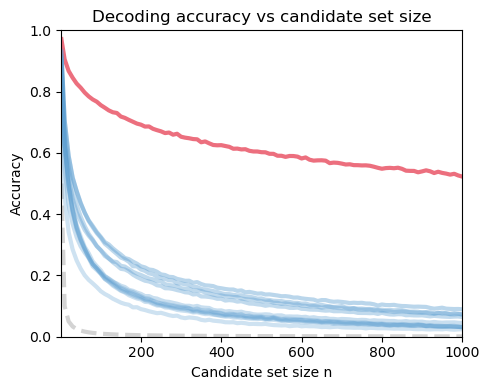

In [9]:
if 'accuracy_curves' in decoding_accuracy_curve and decoding_accuracy_curve['accuracy_curves']:
    n_values = decoding_accuracy_curve['n_values']
    curves = decoding_accuracy_curve['accuracy_curves']
    ref_n = 500
    acc_at_ref = {}
    for model_name, acc_dict in curves.items():
        val = acc_dict.get(ref_n, np.nan)
        if np.isnan(val) and n_values:
            val = acc_dict.get(n_values[-1], np.nan)
        acc_at_ref[model_name] = val
    valid_acc = [v for v in acc_at_ref.values() if np.isfinite(v)]
    a_min = min(valid_acc) if valid_acc else 0
    a_max = max(valid_acc) if valid_acc else 1
    span = a_max - a_min if a_max > a_min else 1

    fig, ax = plt.subplots(figsize=(5, 4))
    chance_y = [1.0 / n for n in n_values]
    ax.plot(n_values, chance_y, color='lightgray', linestyle='--', linewidth=3, label='Chance')

    for model_name, acc_dict in curves.items():
        y = [acc_dict.get(n, np.nan) for n in n_values]
        if 'alexnet' in model_name.lower() and 'fc6' in model_name.lower():
            ax.plot(n_values, y, label=model_name, linewidth=3, color='#EC6F7E')
        else:
            a = acc_at_ref.get(model_name, np.nan)
            alpha = 0.3 + 0.7 * (a - a_min) / span if np.isfinite(a) else 0.5
            ax.plot(n_values, y, label=model_name, linewidth=3, color='#5E9FD1', alpha=alpha)
    ax.set_xlabel('Candidate set size n')
    ax.set_ylabel('Accuracy')
    ax.set_title('Decoding accuracy vs candidate set size')
    ax.set_xlim(min(n_values), max(n_values))
    ax.set_ylim(0, 1)
    plt.tight_layout()
    os.makedirs(decoding_dir, exist_ok=True)
    plt.savefig(os.path.join(decoding_dir, 'decoding_accuracy_curves.pdf'), bbox_inches='tight')
    plt.show()

## Decoding by neuron subset (AlexNet only)

三组神经元设置：1) 数量 80%/60%/40%/20%；2) Tuning type（single/multi/no-tuning）；3) Encoding 性能按相关性分 5 组。

In [21]:
import sys
sys.path.insert(0, '/media/ubuntu/sda/TrippleN/scripts')
from decoding_model_loocv import (
    load_neural_data, reduce_response_dim, reduce_model_dim, loocv_decode,
    decode_one_model, get_image_files, RESPONSE_DIM, MODEL_DIM, RIDGE_ALPHA, N_IMAGES
)
from decoding_accuracy_curve import compute_accuracy_curve, N_VALUES, N_TRIALS, RANDOM_SEED

STIMULI_PATH = '/media/ubuntu/sda/TrippleN/stimuli'
NEURON_RESPONSES_PATH = '/media/ubuntu/sda/TrippleN/customize/neuron_responses_1000.npy'
encoding_dir = '/media/ubuntu/sda/TrippleN/customize/encoding_analysis'

neural_full = np.load(NEURON_RESPONSES_PATH).astype(np.float32).T
if neural_full.shape[0] != N_IMAGES or neural_full.shape[1] != len(unit_info):
    neural_full = load_neural_data()
n_units_total = neural_full.shape[1]

fc6_cache = os.path.join(decoding_dir, 'alexnet_fc6_features_1000.npy')
if os.path.exists(fc6_cache):
    alexnet_fc6 = np.load(fc6_cache).astype(np.float32)
    print('AlexNet fc6 已从缓存加载:', alexnet_fc6.shape)
else:
    import torch
    import predict_neuron_activity_gpu as pnag
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    image_files = get_image_files()
    alexnet = pnag.load_alexnet(device)
    alexnet_fc6 = pnag.extract_fc6_features(image_files, STIMULI_PATH, alexnet, device)
    del alexnet
    pnag.clear_gpu_memory()
    alexnet_fc6 = np.asarray(alexnet_fc6, dtype=np.float32)
    np.save(fc6_cache, alexnet_fc6)
    print('AlexNet fc6 已计算并缓存:', alexnet_fc6.shape)

开始提取 1000 张图像的AlexNet fc6特征...
  已处理 320/1000 张图像
  已处理 640/1000 张图像
  已处理 960/1000 张图像
fc6特征提取完成，特征矩阵形状: (1000, 4096)
AlexNet fc6 已计算并缓存: (1000, 4096)


In [27]:
from scipy.io import loadmat

rng_subset = np.random.default_rng(42)
subset_indices = {}
n_units = neural_full.shape[1]
for pct, label in [(0.8, '80%'), (0.6, '60%'), (0.4, '40%'), (0.2, '20%')]:
    k = max(1, int(n_units * pct))
    idx = rng_subset.choice(n_units, size=k, replace=False)
    subset_indices['quantity_' + label] = np.sort(idx)

n_units_decoding = neural_full.shape[1]
encoding_dir = '/media/ubuntu/sda/TrippleN/customize/encoding_analysis'
unit_info_tuning_path = os.path.join(encoding_dir, 'unit_info_tuning_with_alexnet.pkl')
if os.path.exists(unit_info_tuning_path):
    unit_info_tuning = pd.read_pickle(unit_info_tuning_path)
    if 'cluster_tuning_type' in unit_info_tuning.columns and 'alexnet_nc' in unit_info_tuning.columns:
        n_tuning = len(unit_info_tuning)
        cluster_tuning_type = unit_info_tuning['cluster_tuning_type'].values
        alexnet_nc = np.asarray(unit_info_tuning['alexnet_nc']).ravel()
        idx_no = np.where(cluster_tuning_type == 'no_tuning')[0]
        idx_no = idx_no[idx_no < n_units_decoding]
        idx_single = np.where(cluster_tuning_type == 'single_tuning')[0]
        idx_single = idx_single[idx_single < n_units_decoding]
        idx_multi = np.where(cluster_tuning_type == 'multi_tuning')[0]
        idx_multi = idx_multi[idx_multi < n_units_decoding]
        n_target = len(idx_no)
        subset_indices['tuning_no'] = idx_no
        subset_indices['tuning_single'] = np.sort(rng_subset.choice(idx_single, size=min(len(idx_single), n_target), replace=False))
        subset_indices['tuning_multi'] = np.sort(rng_subset.choice(idx_multi, size=min(len(idx_multi), n_target), replace=False))
        valid = (alexnet_nc >= 0) & (alexnet_nc <= 1)
        valid_idx = np.where(valid)[0]
        valid_idx = valid_idx[valid_idx < n_units_decoding]
        order_valid = valid_idx[np.argsort(alexnet_nc[valid_idx])]
        n_valid = len(order_valid)
        for q in range(5):
            i0, i1 = (q * n_valid) // 5, ((q + 1) * n_valid) // 5
            subset_indices['encoding_q%d' % (q + 1)] = np.sort(order_valid[i0:i1])
        print('tuning 与 encoding 子集来自 unit_info_tuning_with_alexnet.pkl (单元数=%d)' % n_tuning)
    else:
        unit_info_tuning = None
else:
    unit_info_tuning = None
if unit_info_tuning is None:
    from scipy.io import loadmat
    psth_path = '/media/ubuntu/sda/TrippleN/customize/aggregate_response/all_subjects_psth.npy'
    psth_data = np.load(psth_path, mmap_mode='r')
    n_neurons_full = psth_data.shape[0]
    n_stimuli = psth_data.shape[1]
    n_time = psth_data.shape[2]
    n_neurons = min(n_neurons_full, len(unit_info))
    if n_neurons < n_neurons_full:
        print('注意: unit_info 行数(%d) < PSTH 行数(%d)，仅用前 %d 个单元计算 tuning' % (len(unit_info), n_neurons_full, n_neurons))
    best_r_time1 = unit_info['best_r_time1'].values
    best_r_time2 = unit_info['best_r_time2'].values
    neuron_responses_psth = np.zeros((n_neurons, n_stimuli), dtype=np.float32)
    for neuron_idx in range(n_neurons):
        start_time = int(best_r_time1[neuron_idx])
        end_time = int(best_r_time2[neuron_idx])
        if start_time < 0:
            start_time = 0
        if end_time > n_time:
            end_time = n_time
        if end_time <= start_time:
            mid_time = n_time // 2
            start_time = max(0, mid_time - 5)
            end_time = min(n_time, mid_time + 5)
        psth_neuron = psth_data[neuron_idx, :n_stimuli, start_time:end_time]
        neuron_responses_psth[neuron_idx] = np.mean(psth_neuron, axis=1)
    responses_1000 = neuron_responses_psth[:, :1000]
    rmin = responses_1000.min(axis=1, keepdims=True)
    rmax = responses_1000.max(axis=1, keepdims=True)
    R = 2 * (responses_1000.astype(np.float64) - rmin) / (rmax - rmin + 1e-10) - 1
    cluster_info = loadmat('/media/ubuntu/sda/TrippleN/ClusInfo.mat')['Cluster_idx']
    cluster_flat = np.asarray(cluster_info).flatten()
    cluster_ids = np.unique(cluster_flat)
    n_clusters = len(cluster_ids)
    SI_clusters = np.zeros((n_neurons, n_clusters))
    for j in range(n_clusters):
        mask_c = (cluster_flat == cluster_ids[j])
        mask_n = ~mask_c
        m_cat = R[:, mask_c].mean(axis=1)
        m_non = R[:, mask_n].mean(axis=1)
        v_cat = R[:, mask_c].var(axis=1)
        v_non = R[:, mask_n].var(axis=1)
        SI_clusters[:, j] = (m_cat - m_non) / np.sqrt(0.5 * (v_cat + v_non) + 1e-10)
    n_cluster_sel = (SI_clusters > 0.3).sum(axis=1)
    cluster_tuning_type = np.array(['multi_tuning'] * n_neurons)
    cluster_tuning_type[n_cluster_sel == 0] = 'no_tuning'
    cluster_tuning_type[n_cluster_sel == 1] = 'single_tuning'
    idx_no = np.where(cluster_tuning_type == 'no_tuning')[0]
    idx_no = idx_no[idx_no < n_units_decoding]
    idx_single = np.where(cluster_tuning_type == 'single_tuning')[0]
    idx_single = idx_single[idx_single < n_units_decoding]
    idx_multi = np.where(cluster_tuning_type == 'multi_tuning')[0]
    idx_multi = idx_multi[idx_multi < n_units_decoding]
    n_target = len(idx_no)
    subset_indices['tuning_no'] = idx_no
    subset_indices['tuning_single'] = np.sort(rng_subset.choice(idx_single, size=min(len(idx_single), n_target), replace=False))
    subset_indices['tuning_multi'] = np.sort(rng_subset.choice(idx_multi, size=min(len(idx_multi), n_target), replace=False))
    enc_files = [f for f in os.listdir(encoding_dir) if f.endswith('.pkl') and 'alexnet' in f.lower() and 'encoding' in f.lower()]
    alexnet_nc = None
    for f in enc_files:
        with open(os.path.join(encoding_dir, f), 'rb') as fp:
            data = pickle.load(fp)
        if 'normalized_correlation' in data:
            alexnet_nc = np.asarray(data['normalized_correlation']).ravel()
            break
    if alexnet_nc is not None and len(alexnet_nc) >= n_units_decoding:
        valid = (alexnet_nc >= 0) & (alexnet_nc <= 1)
        valid_idx = np.where(valid)[0]
        valid_idx = valid_idx[valid_idx < n_units_decoding]
        order_valid = valid_idx[np.argsort(alexnet_nc[valid_idx])]
        n_valid = len(order_valid)
        for q in range(5):
            i0, i1 = (q * n_valid) // 5, ((q + 1) * n_valid) // 5
            subset_indices['encoding_q%d' % (q + 1)] = np.sort(order_valid[i0:i1])
    else:
        for q in range(5):
            i0 = (q * n_units_decoding) // 5
            i1 = ((q + 1) * n_units_decoding) // 5
            subset_indices['encoding_q%d' % (q + 1)] = np.arange(i0, i1)
    print('未找到 unit_info_tuning_with_alexnet.pkl，已用 PSTH+ClusInfo 计算 tuning 与 encoding 子集')

for k, v in subset_indices.items():
    print(k, len(v))

tuning 与 encoding 子集来自 unit_info_tuning_with_alexnet.pkl (单元数=15652)
quantity_80% 12521
quantity_60% 9391
quantity_40% 6260
quantity_20% 3130
tuning_no 2568
tuning_single 2568
tuning_multi 2568
encoding_q1 2894
encoding_q2 2895
encoding_q3 2894
encoding_q4 2895
encoding_q5 2895


In [30]:
n_values_sub = [2] + list(range(10, 10001, 10))
n_trials_sub = 5000

decoding_by_subset = {'n_values': n_values_sub, 'n_trials': n_trials_sub, 'accuracy_curves': {}, 'mean_corr': {}}

for name, idx in subset_indices.items():
    if len(idx) < 10:
        print('跳过 %s: 神经元数 %d' % (name, len(idx)))
        continue
    neural_sub = neural_full[:, idx].copy()
    n_comp = min(RESPONSE_DIM, neural_sub.shape[1])
    neural_reduced, _ = reduce_response_dim(neural_sub, n_components=n_comp)
    model_reduced, _ = reduce_model_dim(alexnet_fc6, n_components=MODEL_DIM)
    mean_corr, _, predictions, _ = loocv_decode(neural_reduced, model_reduced, alpha=RIDGE_ALPHA)
    decoding_by_subset['mean_corr'][name] = mean_corr
    acc = compute_accuracy_curve(predictions, model_reduced, n_values_sub, n_trials_sub, RANDOM_SEED)
    decoding_by_subset['accuracy_curves'][name] = acc
    print('%s: n=%d, mean_corr=%.4f' % (name, len(idx), mean_corr))

os.makedirs(decoding_dir, exist_ok=True)
with open(os.path.join(decoding_dir, 'decoding_by_subset_alexnet.pkl'), 'wb') as f:
    pickle.dump(decoding_by_subset, f)
print('已保存 decoding_by_subset_alexnet.pkl')

  Response PCA: (1000, 12521) -> (1000, 500), explained variance: 0.8718
  Model PCA: (1000, 4096) -> (1000, 100), explained variance: 0.6214
  执行 LOOCV (1000 折)...
    处理 100/1000
    处理 200/1000
    处理 300/1000
    处理 400/1000
    处理 500/1000
    处理 600/1000
    处理 700/1000
    处理 800/1000
    处理 900/1000
    处理 1000/1000
quantity_80%: n=12521, mean_corr=0.5351
  Response PCA: (1000, 9391) -> (1000, 500), explained variance: 0.8819
  Model PCA: (1000, 4096) -> (1000, 100), explained variance: 0.6214
  执行 LOOCV (1000 折)...
    处理 100/1000
    处理 200/1000
    处理 300/1000
    处理 400/1000
    处理 500/1000
    处理 600/1000
    处理 700/1000
    处理 800/1000
    处理 900/1000
    处理 1000/1000
quantity_60%: n=9391, mean_corr=0.5255
  Response PCA: (1000, 6260) -> (1000, 500), explained variance: 0.8963
  Model PCA: (1000, 4096) -> (1000, 100), explained variance: 0.6214
  执行 LOOCV (1000 折)...
    处理 100/1000
    处理 200/1000
    处理 300/1000
    处理 400/1000
    处理 500/1000
    处理 600/1000
    处理 700

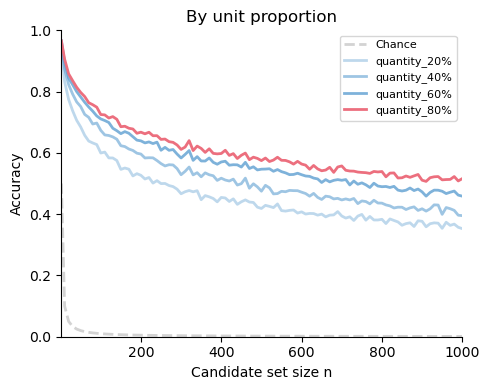

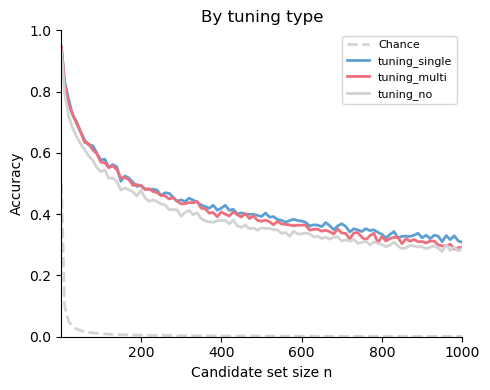

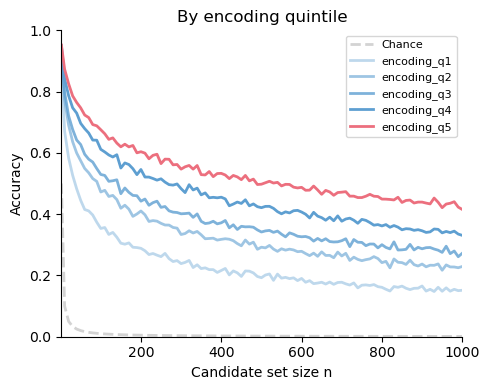

In [12]:
pkl_subset = os.path.join(decoding_dir, 'decoding_by_subset_alexnet.pkl')
try:
    curves = decoding_by_subset['accuracy_curves']
    n_values = decoding_by_subset['n_values']
except NameError:
    if os.path.exists(pkl_subset):
        with open(pkl_subset, 'rb') as f:
            decoding_by_subset = pickle.load(f)
        curves = decoding_by_subset['accuracy_curves']
        n_values = decoding_by_subset['n_values']
    else:
        curves = {}
        n_values = []


def _hex_rgba(hex_color, alpha):
    h = hex_color.lstrip('#')
    r, g, b = (int(h[i:i + 2], 16) / 255.0 for i in (0, 2, 4))
    return (r, g, b, alpha)


if not curves:
    print('无 decoding_by_subset 结果，请先运行上一 cell')
else:
    chance_y = [1.0 / n for n in n_values]
    qty_color = {
        'quantity_80%': '#EC6F7E',
        'quantity_20%': _hex_rgba('#5E9FD1', 0.4),
        'quantity_40%': _hex_rgba('#5E9FD1', 0.6),
        'quantity_60%': _hex_rgba('#5E9FD1', 0.8),
    }
    tuning_color = {
        'tuning_single': '#5E9FD1',
        'tuning_multi': '#EC6F7E',
        'tuning_no': 'lightgray',
    }
    enc_color = {
        'encoding_q5': '#EC6F7E',
        'encoding_q4': _hex_rgba('#5E9FD1', 1.0),
        'encoding_q3': _hex_rgba('#5E9FD1', 0.8),
        'encoding_q2': _hex_rgba('#5E9FD1', 0.6),
        'encoding_q1': _hex_rgba('#5E9FD1', 0.4),
    }
    panels = [
        (
            sorted([k for k in curves if k.startswith('quantity_')]),
            'By unit proportion',
            'decoding_by_subset_alexnet_unit_proportion.pdf',
            qty_color,
        ),
        (
            ['tuning_single', 'tuning_multi', 'tuning_no'],
            'By tuning type',
            'decoding_by_subset_alexnet_tuning.pdf',
            tuning_color,
        ),
        (
            ['encoding_q1', 'encoding_q2', 'encoding_q3', 'encoding_q4', 'encoding_q5'],
            'By encoding quintile',
            'decoding_by_subset_alexnet_encoding.pdf',
            enc_color,
        ),
    ]
    for group, title, fname, cmap in panels:
        fig, ax = plt.subplots(figsize=(5, 4))
        ax.plot(n_values, chance_y, color='lightgray', linestyle='--', linewidth=2, label='Chance')
        for name in group:
            if name not in curves:
                continue
            y = [curves[name].get(n, np.nan) for n in n_values]
            c = cmap.get(name, '#333333')
            ax.plot(n_values, y, linewidth=2, label=name, color=c)
        ax.set_xlabel('Candidate set size n')
        ax.set_ylabel('Accuracy')
        ax.set_title(title)
        ax.set_xlim(min(n_values), 1000)
        ax.set_ylim(0, 1)
        ax.legend(fontsize=8)
        sns.despine(ax=ax)
        plt.tight_layout()
        plt.savefig(os.path.join(decoding_dir, fname), bbox_inches='tight')
        plt.show()
        plt.close(fig)

## AlexNet：神经元 z-score 前后解码准确率（候选集大小 n）

对 `neural_full` 按**每个神经元跨 1000 张图**做 z-score 后，仅用 AlexNet fc6 重新跑 `decode_one_model` 与 `compute_accuracy_curve`，并与 `decoding_accuracy_curve.pkl` 中原始 AlexNet 曲线同图对比（相同的 `n_values`、`n_trials`、`seed`）。

z-score 后重新解码 AlexNet fc6 (LOOCV + 准确率曲线)...

处理模型: alexnet_fc6_zscore
  输入: neural (1000, 15652), model (1000, 4096)
  Response PCA: (1000, 15652) -> (1000, 500), explained variance: 0.7963
  Model PCA: (1000, 4096) -> (1000, 100), explained variance: 0.6214
  执行 LOOCV (1000 折)...
    处理 100/1000
    处理 200/1000
    处理 300/1000
    处理 400/1000
    处理 500/1000
    处理 600/1000
    处理 700/1000
    处理 800/1000
    处理 900/1000
    处理 1000/1000


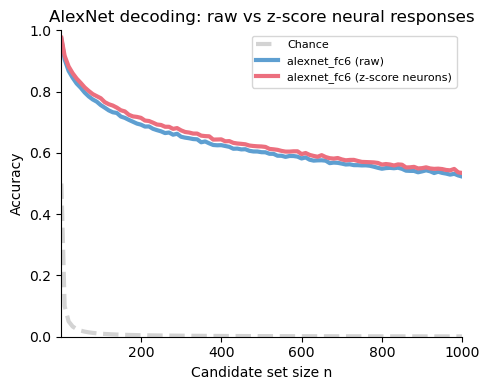

已保存 /media/ubuntu/sda/TrippleN/customize/decoding_analysis/decoding_accuracy_curves_alexnet_zscore_compare.pdf


In [13]:
import sys
sys.path.insert(0, '/media/ubuntu/sda/TrippleN/scripts')
from decoding_model_loocv import decode_one_model, RESPONSE_DIM, MODEL_DIM, RIDGE_ALPHA, N_IMAGES, load_neural_data
from decoding_accuracy_curve import compute_accuracy_curve

_decoding_dir = '/media/ubuntu/sda/TrippleN/customize/decoding_analysis'
_neural_path = '/media/ubuntu/sda/TrippleN/customize/neuron_responses_1000.npy'
_fc6_cache = os.path.join(_decoding_dir, 'alexnet_fc6_features_1000.npy')
_acc_pkl = os.path.join(_decoding_dir, 'decoding_accuracy_curve.pkl')

neural_full_z = np.load(_neural_path).astype(np.float32).T
if neural_full_z.shape[0] != N_IMAGES:
    neural_full_z = load_neural_data()
if not os.path.exists(_fc6_cache):
    raise FileNotFoundError('缺少 AlexNet fc6 缓存，请先运行上方加载 fc6 的 cell: %s' % _fc6_cache)
alexnet_fc6_z = np.load(_fc6_cache).astype(np.float32)

mu = neural_full_z.mean(axis=0, keepdims=True)
sig = neural_full_z.std(axis=0, keepdims=True)
sig = np.where(sig < 1e-10, 1.0, sig)
neural_z = ((neural_full_z - mu) / sig).astype(np.float32)

with open(_acc_pkl, 'rb') as f:
    _dac = pickle.load(f)
n_values_z = list(_dac['n_values'])
n_trials_z = int(_dac['n_trials'])
seed_z = int(_dac['seed'])
curves_z = _dac.get('accuracy_curves', {})

raw_key = None
for k in curves_z:
    if 'alexnet' in k.lower() and 'fc6' in k.lower():
        raw_key = k
        break
acc_raw_dict = curves_z[raw_key] if raw_key else {}
if raw_key is None:
    print('decoding_accuracy_curve.pkl 中未找到 alexnet fc6 键，仅绘制 z-score 曲线')

print('z-score 后重新解码 AlexNet fc6 (LOOCV + 准确率曲线)...')
res_z = decode_one_model(neural_z, alexnet_fc6_z, 'alexnet_fc6_zscore')
acc_zscore = compute_accuracy_curve(
    np.asarray(res_z['predictions'], dtype=np.float64),
    np.asarray(res_z['target_reduced'], dtype=np.float64),
    n_values_z,
    n_trials_z,
    seed_z,
)

fig, ax = plt.subplots(figsize=(5, 4))
chance_y = [1.0 / n for n in n_values_z]
ax.plot(n_values_z, chance_y, color='lightgray', linestyle='--', linewidth=3, label='Chance')
if acc_raw_dict:
    y_raw = [acc_raw_dict.get(n, np.nan) for n in n_values_z]
    ax.plot(n_values_z, y_raw, linewidth=3, color='#5E9FD1', label='%s (raw)' % raw_key)
y_zs = [acc_zscore.get(n, np.nan) for n in n_values_z]
ax.plot(n_values_z, y_zs, linewidth=3, color='#EC6F7E', label='alexnet_fc6 (z-score neurons)')
ax.set_xlabel('Candidate set size n')
ax.set_ylabel('Accuracy')
ax.set_title('AlexNet decoding: raw vs z-score neural responses')
ax.set_xlim(min(n_values_z), max(n_values_z))
ax.set_ylim(0, 1)
ax.legend(fontsize=8)
sns.despine(ax=ax)
plt.tight_layout()
_out_z = os.path.join(_decoding_dir, 'decoding_accuracy_curves_alexnet_zscore_compare.pdf')
plt.savefig(_out_z, bbox_inches='tight')
plt.show()
print('已保存', _out_z)

## AlexNet fc6：模型侧 PCA 维度 100 vs 500

在**神经元侧 PCA 维度不变**（默认与 `RESPONSE_DIM` 一致）的前提下，将 **fc6 经 PCA 压到 500 维** 再跑 LOOCV 与 `compute_accuracy_curve`，与 `decoding_accuracy_curve.pkl` 中原始结果（通常为 **100 维** 模型 PCA）对比。命令行也可用：`python decoding_model_loocv.py --models alexnet --model-dim 500`（需自行保存/合并 pkl）。

AlexNet fc6: model PCA 500 维 (baseline pkl 多为 100 维)...

处理模型: alexnet_fc6_model_pca500
  输入: neural (1000, 15652), model (1000, 4096)
  Response PCA: (1000, 15652) -> (1000, 500), explained variance: 0.8665
  Model PCA: (1000, 4096) -> (1000, 500), explained variance: 0.9105
  执行 LOOCV (1000 折)...
    处理 100/1000
    处理 200/1000
    处理 300/1000
    处理 400/1000
    处理 500/1000
    处理 600/1000
    处理 700/1000
    处理 800/1000
    处理 900/1000
    处理 1000/1000
  mean_corr = 0.3796


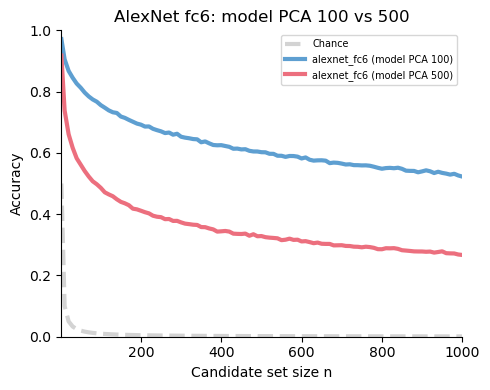

已保存 /media/ubuntu/sda/TrippleN/customize/decoding_analysis/decoding_accuracy_curves_alexnet_model_pca500_compare.pdf


In [3]:
import sys
import importlib
sys.path.insert(0, '/media/ubuntu/sda/TrippleN/scripts')
import decoding_model_loocv as _dml
importlib.reload(_dml)
decode_one_model = _dml.decode_one_model
MODEL_DIM = _dml.MODEL_DIM
RIDGE_ALPHA = _dml.RIDGE_ALPHA
N_IMAGES = _dml.N_IMAGES
load_neural_data = _dml.load_neural_data
from decoding_accuracy_curve import compute_accuracy_curve

_mdir = '/media/ubuntu/sda/TrippleN/customize/decoding_analysis'
_neu = '/media/ubuntu/sda/TrippleN/customize/neuron_responses_1000.npy'
_fc6p = os.path.join(_mdir, 'alexnet_fc6_features_1000.npy')
_accp = os.path.join(_mdir, 'decoding_accuracy_curve.pkl')
_model_dim_test = 500

_neural_m = np.load(_neu).astype(np.float32).T
if _neural_m.shape[0] != N_IMAGES:
    _neural_m = load_neural_data()
if not os.path.exists(_fc6p):
    raise FileNotFoundError('缺少 fc6 缓存，请先运行加载 AlexNet fc6 的 cell: %s' % _fc6p)
_fc6_m = np.load(_fc6p).astype(np.float32)

with open(_accp, 'rb') as f:
    _dac_m = pickle.load(f)
_nv_m = list(_dac_m['n_values'])
_nt_m = int(_dac_m['n_trials'])
_sd_m = int(_dac_m['seed'])
_cv_m = _dac_m.get('accuracy_curves', {})

_raw_k = None
for _k in _cv_m:
    if 'alexnet' in _k.lower() and 'fc6' in _k.lower():
        _raw_k = _k
        break
_acc100 = _cv_m[_raw_k] if _raw_k else {}
if _raw_k is None:
    print('decoding_accuracy_curve.pkl 中未找到 alexnet fc6，仅绘制 model PCA %d 曲线' % _model_dim_test)

print('AlexNet fc6: model PCA %d 维 (baseline pkl 多为 %d 维)...' % (_model_dim_test, MODEL_DIM))
_res_m = decode_one_model(_neural_m, _fc6_m, 'alexnet_fc6_model_pca%d' % _model_dim_test, model_dim=_model_dim_test)
print('  mean_corr = %.4f' % _res_m['mean_corr'])
_acc500 = compute_accuracy_curve(
    np.asarray(_res_m['predictions'], dtype=np.float64),
    np.asarray(_res_m['target_reduced'], dtype=np.float64),
    _nv_m,
    _nt_m,
    _sd_m,
)

fig, ax = plt.subplots(figsize=(5, 4))
_ch = [1.0 / n for n in _nv_m]
ax.plot(_nv_m, _ch, color='lightgray', linestyle='--', linewidth=3, label='Chance')
if _acc100:
    _y1 = [_acc100.get(n, np.nan) for n in _nv_m]
    ax.plot(_nv_m, _y1, linewidth=3, color='#5E9FD1', label='%s (model PCA %d)' % (_raw_k, MODEL_DIM))
_y5 = [_acc500.get(n, np.nan) for n in _nv_m]
ax.plot(_nv_m, _y5, linewidth=3, color='#EC6F7E', label='alexnet_fc6 (model PCA %d)' % _model_dim_test)
ax.set_xlabel('Candidate set size n')
ax.set_ylabel('Accuracy')
ax.set_title('AlexNet fc6: model PCA %d vs %d' % (MODEL_DIM, _model_dim_test))
ax.set_xlim(min(_nv_m), max(_nv_m))
ax.set_ylim(0, 1)
ax.legend(fontsize=7)
sns.despine(ax=ax)
plt.tight_layout()
_out_m = os.path.join(_mdir, 'decoding_accuracy_curves_alexnet_model_pca500_compare.pdf')
plt.savefig(_out_m, bbox_inches='tight')
plt.show()
print('已保存', _out_m)

In [5]:
import pickle
from scipy.spatial.distance import cdist
from PIL import Image

_ddir_nn = '/media/ubuntu/sda/TrippleN/customize/decoding_analysis'
_loocv_p = os.path.join(_ddir_nn, 'decoding_results_loocv.pkl')
_stim_dir = '/media/ubuntu/sda/TrippleN/stimuli'
_out_nn = os.path.join(_ddir_nn, 'loocv_per_stim_original_image_nn_fc6_100d.pkl')

with open(_loocv_p, 'rb') as f:
    _loocv_d = pickle.load(f)
_alex = _loocv_d['alexnet_fc6']
_pca_fc6 = _alex['pca_model']
_pca_mean_fc6 = np.asarray(_pca_fc6.mean_, dtype=np.float32)
_pca_comp_fc6 = np.asarray(_pca_fc6.components_, dtype=np.float32)
_pred = np.asarray(_alex['predictions'], dtype=np.float64)
_tgt = np.asarray(_alex['target_reduced'], dtype=np.float64)
_dmat = cdist(_pred, _tgt, metric='euclidean')
_nn = np.argmin(_dmat, axis=1).astype(np.int32)

_bmp = sorted([x for x in os.listdir(_stim_dir) if x.lower().endswith('.bmp')])[:1000]
if len(_bmp) < 1000:
    raise ValueError('stimuli 不足 1000 张 bmp')
_orig_imgs = []
for _fn in _bmp:
    _orig_imgs.append(np.asarray(Image.open(os.path.join(_stim_dir, _fn)), dtype=np.uint8))
_orig_imgs = np.stack(_orig_imgs, axis=0)
_nn_fc6 = _tgt[_nn].astype(np.float32)
_correct = (_nn == np.arange(1000, dtype=np.int32))

_nn_pack = {
    'model': 'alexnet_fc6',
    'space': 'target_reduced_100d_pca',
    'neighbor_rule': 'argmin_j euclidean(pred[i], target[j])',
    'decode_correct': _correct,
    'image_filenames': _bmp,
    'nn_stimulus_idx': _nn,
    'original_images_uint8': _orig_imgs,
    'nn_alexnet_fc6_100d': _nn_fc6,
    'alexnet_fc6_pca_mean': _pca_mean_fc6,
    'alexnet_fc6_pca_components': _pca_comp_fc6,
}
with open(_out_nn, 'wb') as f:
    pickle.dump(_nn_pack, f, protocol=pickle.HIGHEST_PROTOCOL)
print('saved', _out_nn)
print('original_images_uint8', _orig_imgs.shape, 'nn_alexnet_fc6_100d', _nn_fc6.shape)
print('decode_correct mean', float(np.mean(_correct)), 'n_correct', int(np.sum(_correct)))
print('alexnet_fc6_pca_mean', _pca_mean_fc6.shape, 'alexnet_fc6_pca_components', _pca_comp_fc6.shape)

saved /media/ubuntu/sda/TrippleN/customize/decoding_analysis/loocv_per_stim_original_image_nn_fc6_100d.pkl
original_images_uint8 (1000, 227, 227, 3) nn_alexnet_fc6_100d (1000, 100)
decode_correct mean 0.528 n_correct 528
alexnet_fc6_pca_mean (4096,) alexnet_fc6_pca_components (100, 4096)
